<a href="https://colab.research.google.com/github/fedhawaq/BOOTCAMP-TASK-ONE/blob/main/DAY-ONE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Task 1: Loading and Exploring Data**

In [8]:
from google.colab import files
uploaded = files.upload()

Saving Sample - Superstore.csv to Sample - Superstore.csv


In [10]:
import pandas as pd

# Load dataset
df = pd.read_csv("Sample - Superstore.csv", encoding='latin1')

# First rows
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [12]:
# Structure
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [13]:
# Summary statistics
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


Dataset contains sales, profit, customers, regions, etc.
Mixed data types (numeric, categorical, dates)

#**Step 2: Data Cleaning**

In [14]:
# Missing values
df.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


In [25]:
df.fillna(method='ffill', inplace=True) #filling the missing values with its previous row value, but in our case there is no missing value as we seen from the above result.

/tmp/ipykernel_2429/696694163.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True) #filling the missing values with its previous row value, but in our case there is no missing value as we seen from the above result.


# converting data sets:




In [16]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

#**Task 3: Feature Engineering**

In [26]:
# Extract Year & Month to make the data easy to analyses separately
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month

In [27]:
# Profit Ratio
df['Profit Ratio'] = df['Profit'] / df['Sales']

In [29]:
df[['Sales','Profit','Profit Ratio']].head()

,Sales,Profit,Profit Ratio
0,261.9600,41.9136,0.1600
1,731.9400,219.5820,0.3000
2,14.6200,6.8714,0.4700
3,957.5775,-383.0310,-0.4000
4,22.3680,2.5164,0.1125


as we in the above our new column is logically correct since all values are filled

#**Task 4: GroupBy and Aggregation**

In [20]:
sales_category = df.groupby('Category')['Sales'].sum()
sales_category

,Sales
Category,
Furniture,741999.7953
Office Supplies,719047.0320
Technology,836154.0330


In [30]:
sales_category = df.groupby('Category')['Sales'].sum()  # sales by category

profit_region = df.groupby('Region')['Profit'].sum()  # profit by region

monthly_sales = df.groupby(['Year','Month'])['Sales'].sum()  # monthly trend

#**Task 5: Pivot Tables**

In [31]:
# Pivot table: total sales by category and region
pivot1 = pd.pivot_table(df, values='Sales', index='Category', columns='Region', aggfunc='sum')
pivot1

# Pivot table: sales trend by segment over months
pivot2 = pd.pivot_table(df, values='Sales', index='Month', columns='Segment', aggfunc='sum')
pivot2

# Pivot table: total profit by sub-category
pivot3 = pd.pivot_table(df, values='Profit', index='Sub-Category', aggfunc='sum')
pivot3

,Profit
Sub-Category,
Accessories,41936.6357
Appliances,18138.0054
Art,6527.7870
Binders,30221.7633
Bookcases,-3472.5560
Chairs,26590.1663
Copiers,55617.8249
Envelopes,6964.1767
Fasteners,949.5182


#**Task 6: Data Splitting & Merging**

In [32]:
# Split dataset: keep sales-related columns
df_sales = df[['Order ID', 'Sales', 'Customer Name']]

# Split dataset: keep profit-related columns
df_profit = df[['Order ID', 'Profit']]

# Merge both datasets on 'Order ID'
merged_df = pd.merge(df_sales, df_profit, on='Order ID')

# Display merged result
merged_df.head()

,Order ID,Sales,Customer Name,Profit
0,CA-2016-152156,261.96,Claire Gute,41.9136
1,CA-2016-152156,261.96,Claire Gute,219.5820
2,CA-2016-152156,731.94,Claire Gute,41.9136
3,CA-2016-152156,731.94,Claire Gute,219.5820
4,CA-2016-138688,14.62,Darrin Van Huff,6.8714


#**Task 7: Data Visualization**

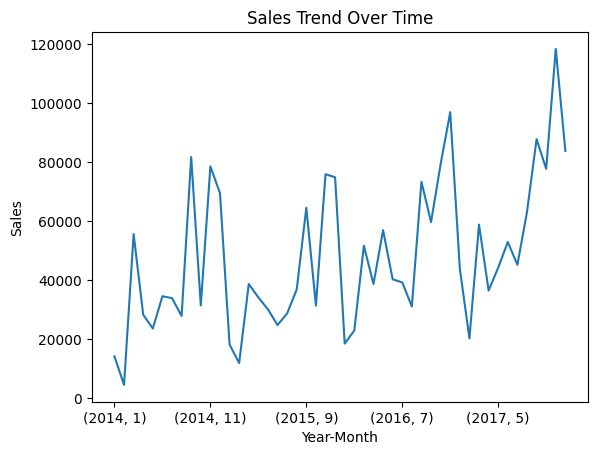

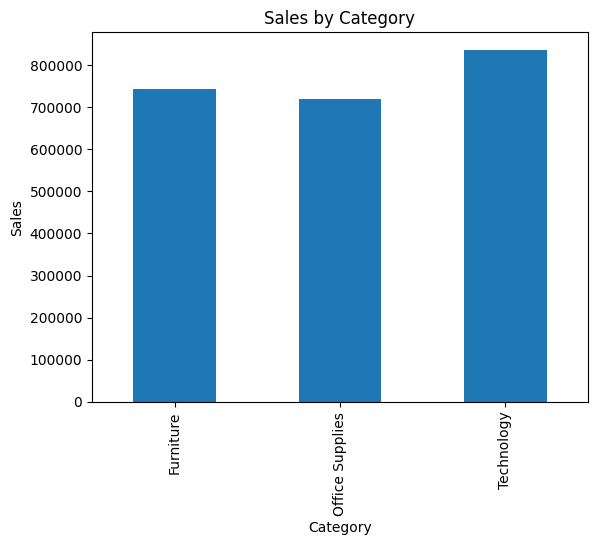

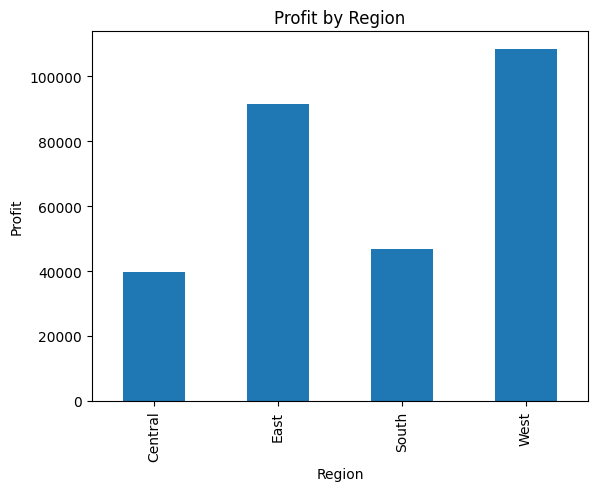

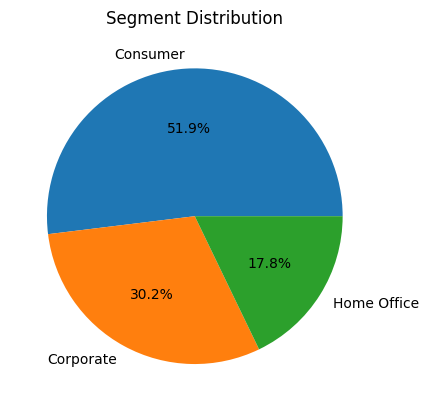

In [33]:
import matplotlib.pyplot as plt  # Import plotting library

# Line chart: sales trend over time
monthly_sales.plot()
plt.title("Sales Trend Over Time")
plt.xlabel("Year-Month")
plt.ylabel("Sales")
plt.show()

# Bar chart: sales by category
sales_category.plot(kind='bar')
plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Sales")
plt.show()

# Bar chart: profit by region
profit_region.plot(kind='bar')
plt.title("Profit by Region")
plt.xlabel("Region")
plt.ylabel("Profit")
plt.show()

# Pie chart: distribution of customer segments
df['Segment'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title("Segment Distribution")
plt.ylabel("")  # Remove y-axis label
plt.show()

#**MY INSIGHTS**

1. Most Profitable Category

From the analysis, it is clear that Technology is the most profitable category in the dataset.

👉 This shows that technology products bring in higher returns compared to Furniture and Office Supplies. It suggests that the business performs better when focusing more on high-value tech products.

2. Least Performing Region

The Central region has the lowest profit compared to the other regions.

👉 This could be because of lower sales, higher discounts, or higher operational costs. It shows that this region may need better marketing or improved business strategies to perform well.

3. Relationship Between Sales and Profit

There is a positive relationship between sales and profit.

👉 This means that when sales increase, profit also tends to increase. However, the relationship is not always perfect since discounts and costs can reduce profit even when sales are high.

4. Sales Trends Over Time

Sales show ups and downs over time, with clear peaks in some months and drops in others.

👉 This indicates that sales are affected by seasonal demand, promotions, or business cycles. Some months perform much better than others, showing clear patterns in customer buying behavior.